In [53]:
import os
import sys
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns


In [54]:
import celloracle as co
co.__version__

'0.14.0'

In [55]:
# visualization settings
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

In [204]:
def read_aracne_out(filename):
    return pd.read_csv(filename, sep='\t')

def read_genie3_out(filename):
    return pd.read_csv(filename, sep='\t')

def read_scenic_out(filename):
    return pd.read_csv(filename, skiprows=3, header=None)

def aracne_out_to_co(
    df,
    copy=False,
):
    """Converts the output of ARACNE to a CellOracle compatible format."""
    if copy:
        df = df.copy()
    df.rename(columns={"Regulator": "source", "Target": "target", "MI": "weight", "pvalue": "p"}, inplace=True)
    df["coef_abs"] = df["weight"].abs()
    return df if copy else None

def genie3_out_to_co(
    df,
    copy=False,
):
    """Converts the output of GENIE3 to a CellOracle compatible format."""
    if copy:
        df = df.copy()
    df.rename(columns={"TF": "source", "importance": "weight"}, inplace=True)
    df["p"] = np.nan
    df["coef_abs"] = df["weight"].abs()
    return df if copy else None

def scenic_out_to_co(
    df
):
    """Co"""
    rows = []
    for i, row in df.iterrows():
        tf = row[0]
        target_string = row[8]
        target_list = target_string.rstrip("]").lstrip("[").split("),")
        for target in target_list:
            target = target.replace("(", "").replace("'", "")
            target_split = target.split(",")
            targ = target_split[0].strip()
            weight = float(target_split[1].strip().strip(")"))
            rows.append([tf, targ, weight])
    return_df = pd.DataFrame(rows, columns=["source", "target", "weight"])
    return_df["p"] = np.nan
    return_df["coef_abs"] = return_df["weight"].abs()
    return return_df

In [221]:
main_dir = "/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference"
dataset = "igvf_b01_LeftCortex"
figure_dir = "/cellar/users/aklie/projects/igvf/sandbox/igvf_b01_LeftCortex/figures"
output_dir = "/cellar/users/aklie/projects/igvf/sandbox/igvf_b01_LeftCortex/output"

In [206]:
aracne_adj_files = glob.glob(os.path.join(main_dir, "aracne", "results", dataset, "2000", "**", "tfs", "network.txt"))
genie3_adj_files = glob.glob(os.path.join(main_dir, "genie3", "results", dataset, "*_adj.tsv"))
grnboost2_adj_files = glob.glob(os.path.join(main_dir, "grnboost2", "results", dataset, "*_adj.tsv"))
scenic_adj_files = glob.glob(os.path.join(main_dir, "scenic", "results", dataset, "0.05", "*_reg.csv"))
all_adj_files = aracne_adj_files + genie3_adj_files + grnboost2_adj_files + scenic_adj_files
all_adj_files

['/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/aracne/results/igvf_b01_LeftCortex/2000/Microglia_CASTJ/tfs/network.txt',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/aracne/results/igvf_b01_LeftCortex/2000/Microglia_B6J/tfs/network.txt',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/genie3/results/igvf_b01_LeftCortex/Microglia_CASTJ_adj.tsv',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/genie3/results/igvf_b01_LeftCortex/Microglia_B6J_adj.tsv',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/grnboost2/results/igvf_b01_LeftCortex/Microglia_B6J_adj.tsv',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/grnboost2/results/igvf_b01_LeftCortex/Microglia_CASTJ_adj.tsv',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/scenic/results/igvf_b01_LeftCortex/0.05/Microglia_B6J_reg.csv',
 '/cellar/users/aklie/projects/igvf/topic_grn_links/grn_inference/scenic/results/i

In [214]:
links_dict = {}
for file in all_adj_files:
    method = file.split('/')[8]
    if method == "aracne":
        df = read_aracne_out(file)
        aracne_out_to_co(df)
        celltype = file.split('/')[-3]
    elif method in ["genie3", "grnboost2"]:
        df = read_genie3_out(file)
        genie3_out_to_co(df)
        celltype = file.split('/')[-1].split(".")[0]
    elif method == "scenic":
        df = read_scenic_out(file)
        df = scenic_out_to_co(df)
        celltype = file.split('/')[-1].split(".")[0]
    print(method, celltype)
    links_dict[method + "_" + celltype] = df

aracne Microglia_CASTJ
aracne Microglia_B6J
genie3 Microglia_CASTJ_adj
genie3 Microglia_B6J_adj
grnboost2 Microglia_B6J_adj
grnboost2 Microglia_CASTJ_adj
scenic Microglia_B6J_reg
scenic Microglia_CASTJ_reg


In [254]:
links = co.Links(name="aracne_genie3_grnboost2_scenic_Microglia_comparison", links_dict=links_dict)

In [255]:
links.filter_links(weight="weight", p=None, threshold_number=2000)

aracne_Microglia_CASTJ


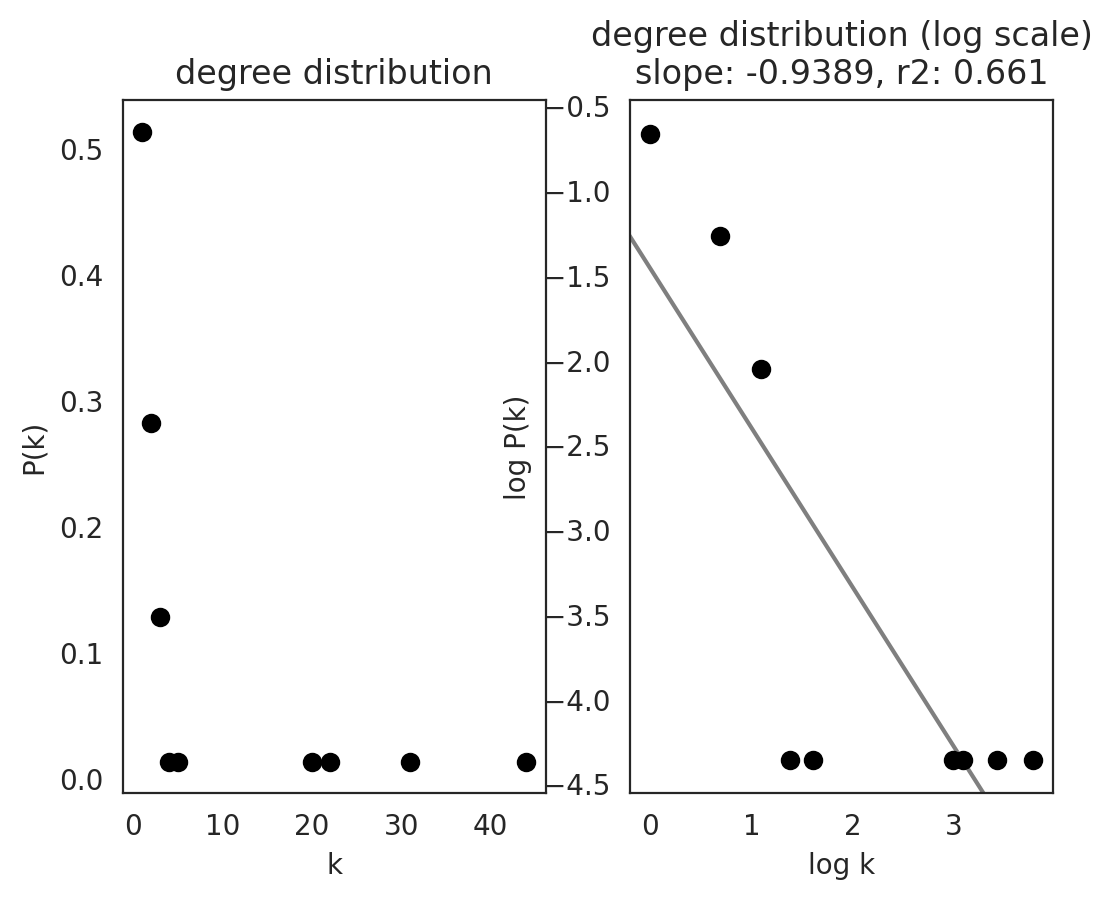

aracne_Microglia_B6J


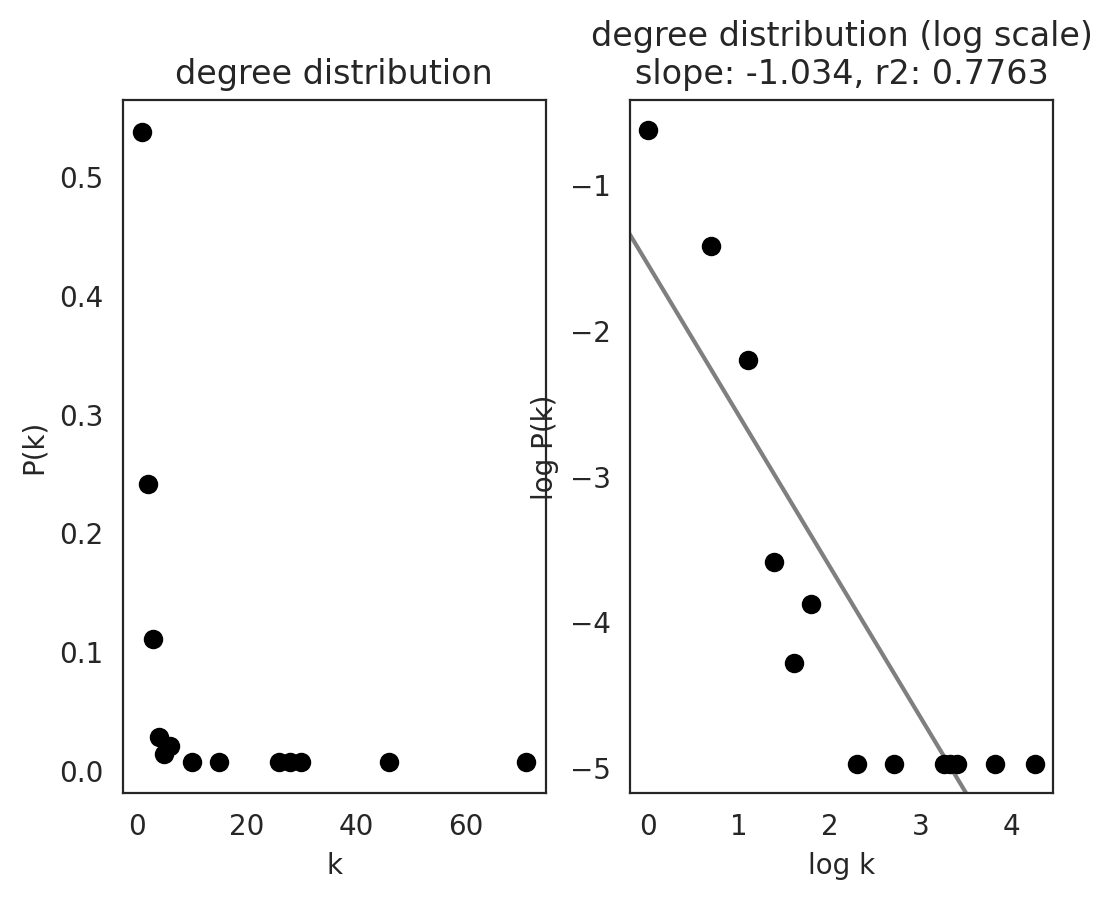

genie3_Microglia_CASTJ_adj


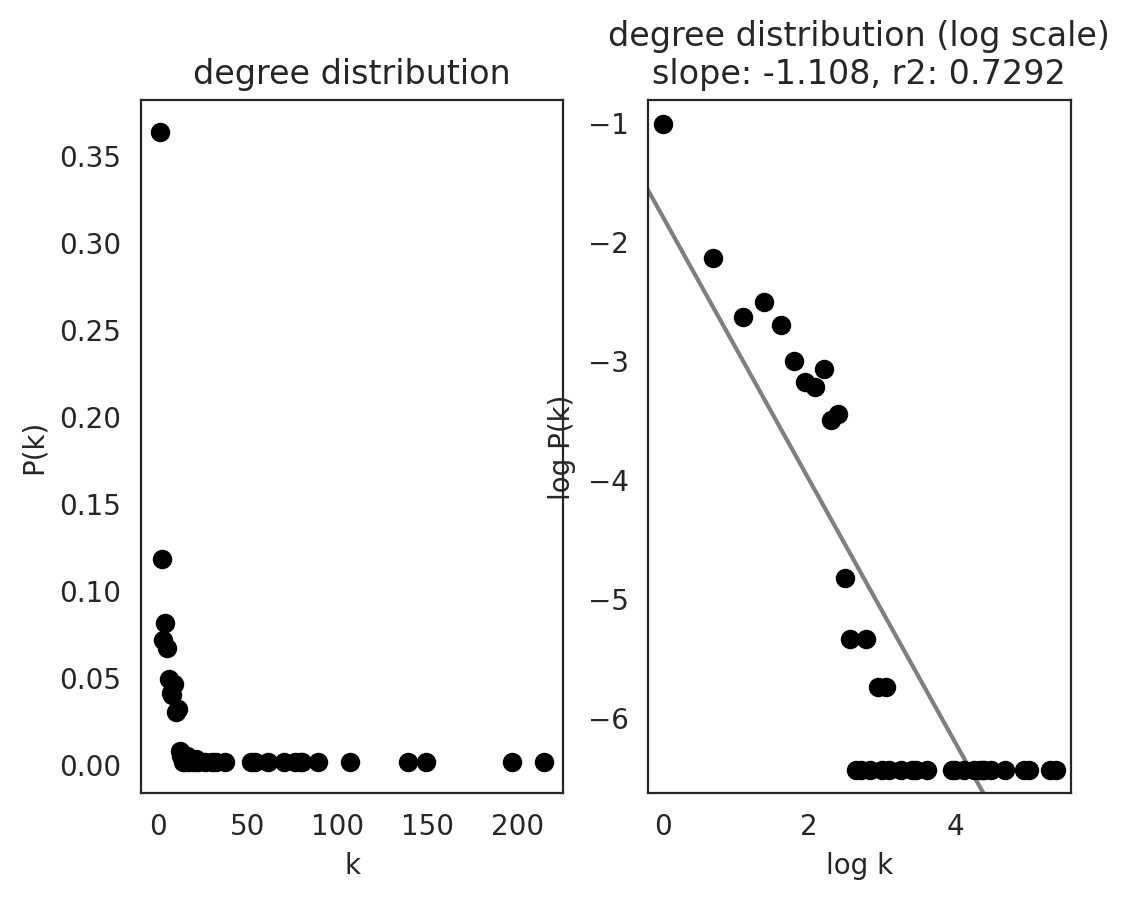

genie3_Microglia_B6J_adj


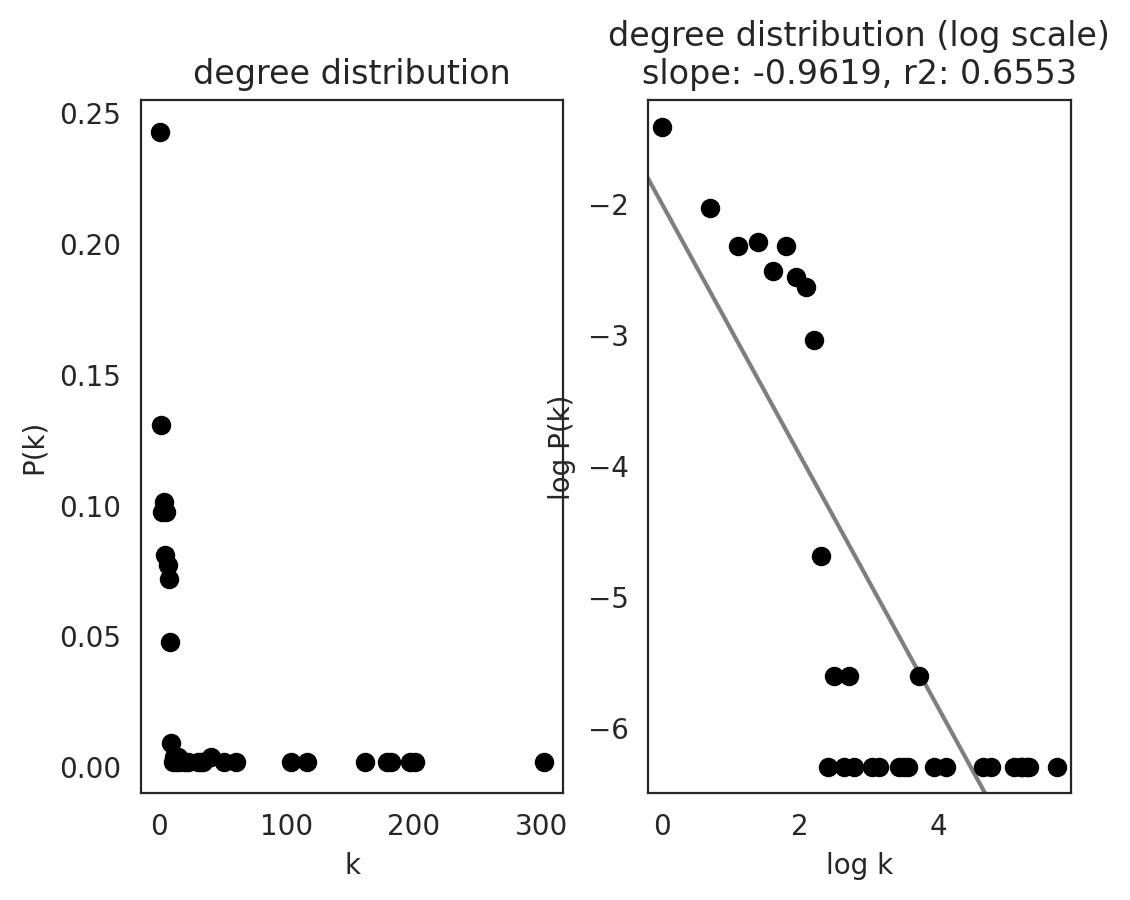

grnboost2_Microglia_B6J_adj


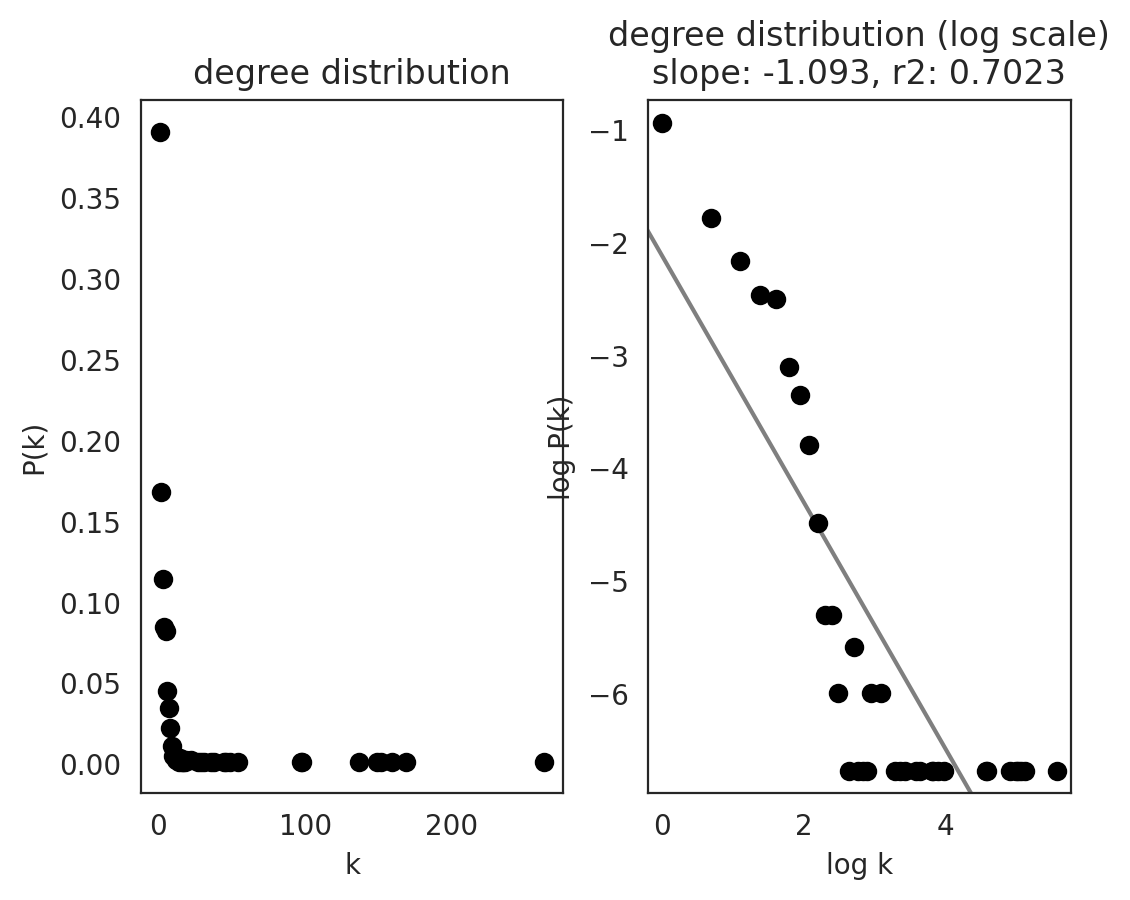

grnboost2_Microglia_CASTJ_adj


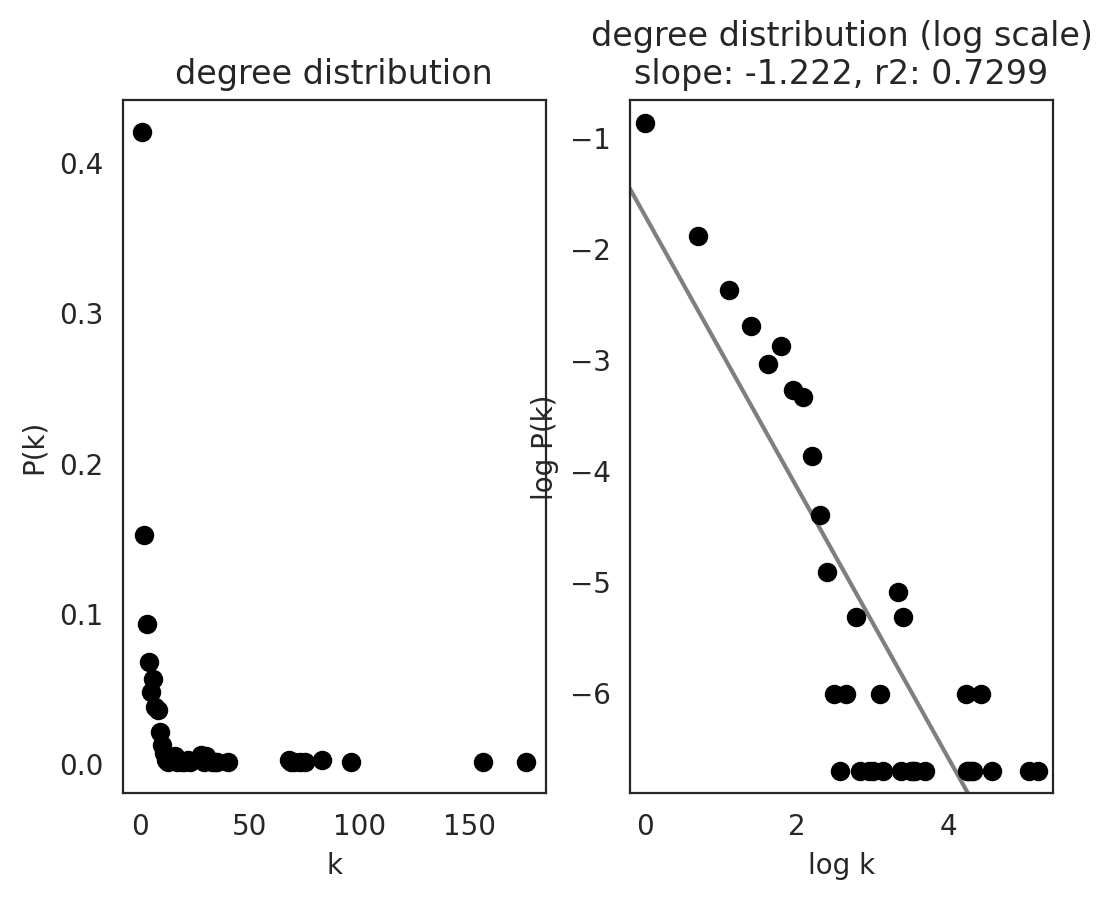

scenic_Microglia_B6J_reg


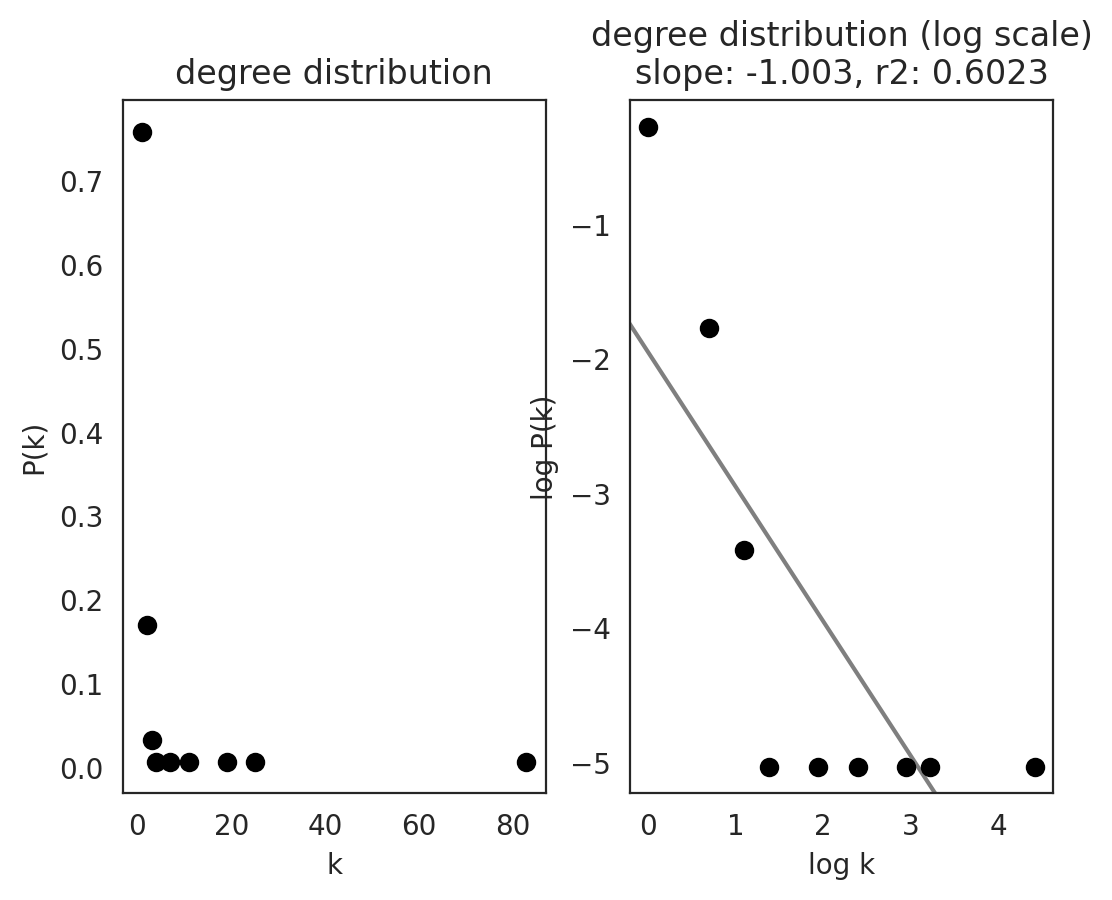

scenic_Microglia_CASTJ_reg


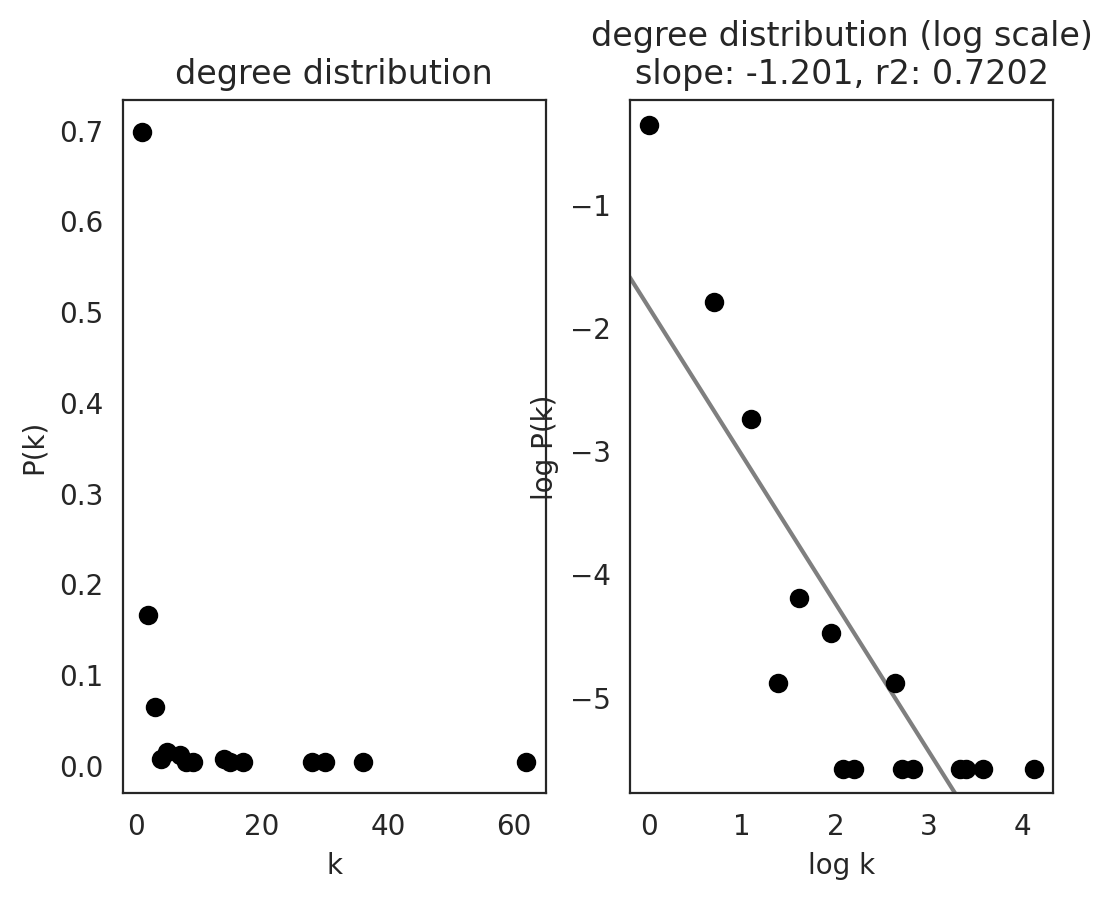

In [256]:
links.plot_degree_distributions(plot_model=True, save=figure_dir)

In [257]:
# Calculate network scores.
links.get_network_score()

In [258]:
gene_scores = links.merged_score
gene_scores.to_csv(os.path.join(output_dir, "celloracle_gene_scores.tsv"), sep="\t")

In [259]:
gene_scores["cluster"].value_counts()

grnboost2_Microglia_CASTJ_adj    816
grnboost2_Microglia_B6J_adj      804
genie3_Microglia_CASTJ_adj       627
genie3_Microglia_B6J_adj         544
scenic_Microglia_CASTJ_reg       265
scenic_Microglia_B6J_reg         153
aracne_Microglia_B6J             145
aracne_Microglia_CASTJ            78
Name: cluster, dtype: int64

In [260]:
# Visualize top n-th genes with high scores.
#links.plot_scores_as_rank(cluster="grnboost2_Microglia_B6J_adj", n_gene=30)

In [261]:
# Visualize top n-th genes with high scores.
#links.plot_scores_as_rank(cluster="grnboost2_Microglia_CASTJ_adj", n_gene=30)

In [237]:
# I want to take the top 10 "eigenvector_centrality" scores for each "cluster" and turn them into a nicely labeled heatmap

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
Pbx1,23,0.298701,2,0.025974,21,0.272727,61.0,0.751141,aracne_Microglia_CASTJ
Srrm2,5,0.064935,5,0.064935,0,0.000000,0.0,0.490720,aracne_Microglia_CASTJ
Zeb2,21,0.272727,2,0.025974,19,0.246753,52.0,0.575741,aracne_Microglia_CASTJ
Celf2,3,0.038961,3,0.038961,0,0.000000,0.0,0.272094,aracne_Microglia_CASTJ
Kmt2a,32,0.415584,1,0.012987,31,0.402597,74.0,0.558546,aracne_Microglia_CASTJ
...,...,...,...,...,...,...,...,...,...
Tnrc6b,5,0.018939,5,0.018939,0,0.000000,0.0,0.000056,scenic_Microglia_CASTJ_reg
Pde4b,1,0.003788,1,0.003788,0,0.000000,0.0,0.002398,scenic_Microglia_CASTJ_reg
Braf,3,0.011364,3,0.011364,0,0.000000,0.0,0.003202,scenic_Microglia_CASTJ_reg
Celf1,3,0.011364,3,0.011364,0,0.000000,0.0,0.000114,scenic_Microglia_CASTJ_reg


In [263]:
unique_genes = set()
for name, df in links.filtered_links.items():
    unique_genes.update(df['source'].unique())
    unique_genes.update(df['target'].unique())

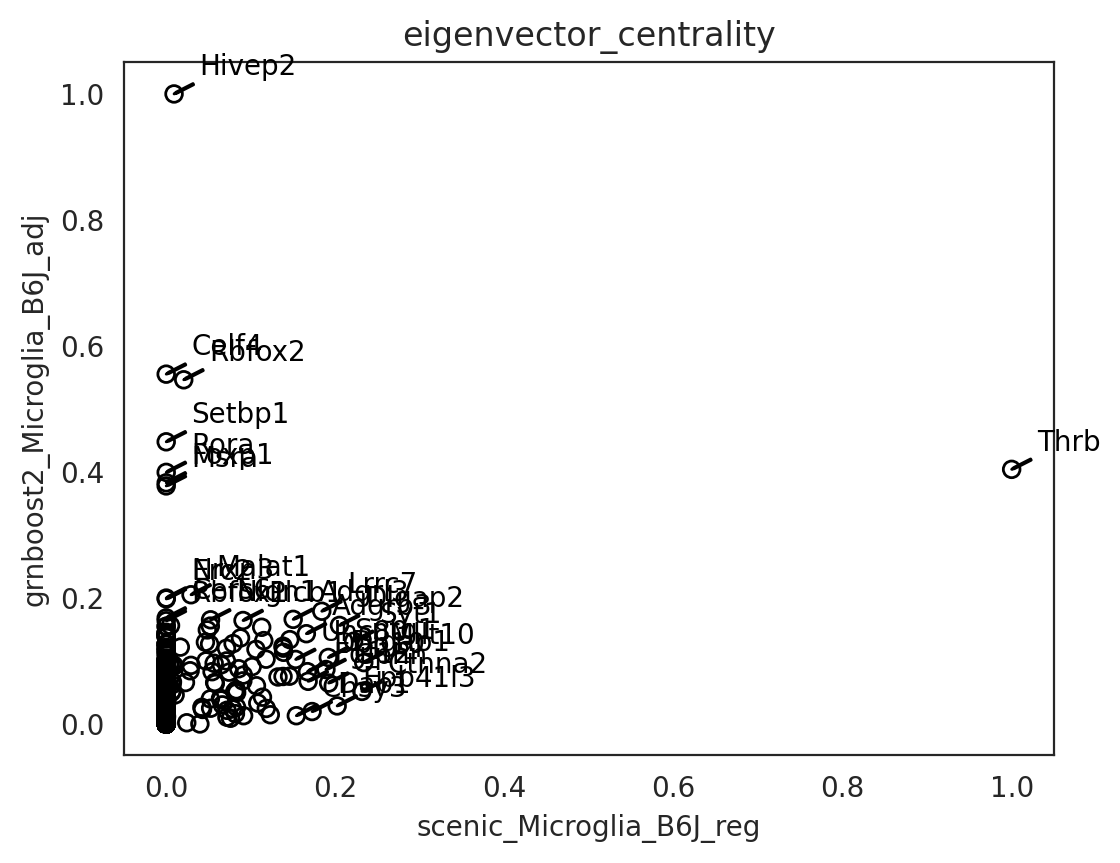

In [246]:
links.plot_score_comparison_2D(value="eigenvector_centrality",
                               cluster1="scenic_Microglia_B6J_reg", cluster2="grnboost2_Microglia_B6J_adj",
                               percentile=98)

In [267]:
unique_genes = gene_scores.index.unique()

In [280]:
links.filtered_links.keys()

dict_keys(['aracne_Microglia_CASTJ', 'aracne_Microglia_B6J', 'genie3_Microglia_CASTJ_adj', 'genie3_Microglia_B6J_adj', 'grnboost2_Microglia_B6J_adj', 'grnboost2_Microglia_CASTJ_adj', 'scenic_Microglia_B6J_reg', 'scenic_Microglia_CASTJ_reg'])

In [283]:
b6j_links = links.filtered_links["grnboost2_Microglia_B6J_adj"]
castj_links = links.filtered_links["grnboost2_Microglia_CASTJ_adj"]

In [284]:
def links_to_adj(links_df, adj_genes):
    """Turn a CellOracle Links dataframe into an adjacency list
    
    Parameters
    ----------
    links_df : pandas.DataFrame
        A CellOracle Links dataframe. Must have columns "source" and "target".
    
    Returns
    -------
    pd.DataFrame
        Adjacency list representation of the links dataframe. Each row represents a unique "source" node, 
        each column a unique "target" node. The value of each cell should be 1 if there is a row in the input 
        links_df with the corresponding source and target nodes, and 0 otherwise.
    """
    adj = pd.DataFrame(0, index=adj_genes, columns=adj_genes)
    for i in range(len(links_df)):
        adj.loc[links_df.iloc[i]["source"], links_df.iloc[i]["target"]] = links_df["weight"][i]
    return adj

In [285]:
b6j_adj_list = links_to_adj(b6j_links, unique_genes)
castj_adj_list = links_to_adj(castj_links, unique_genes)

<AxesSubplot: ylabel='Frequency'>

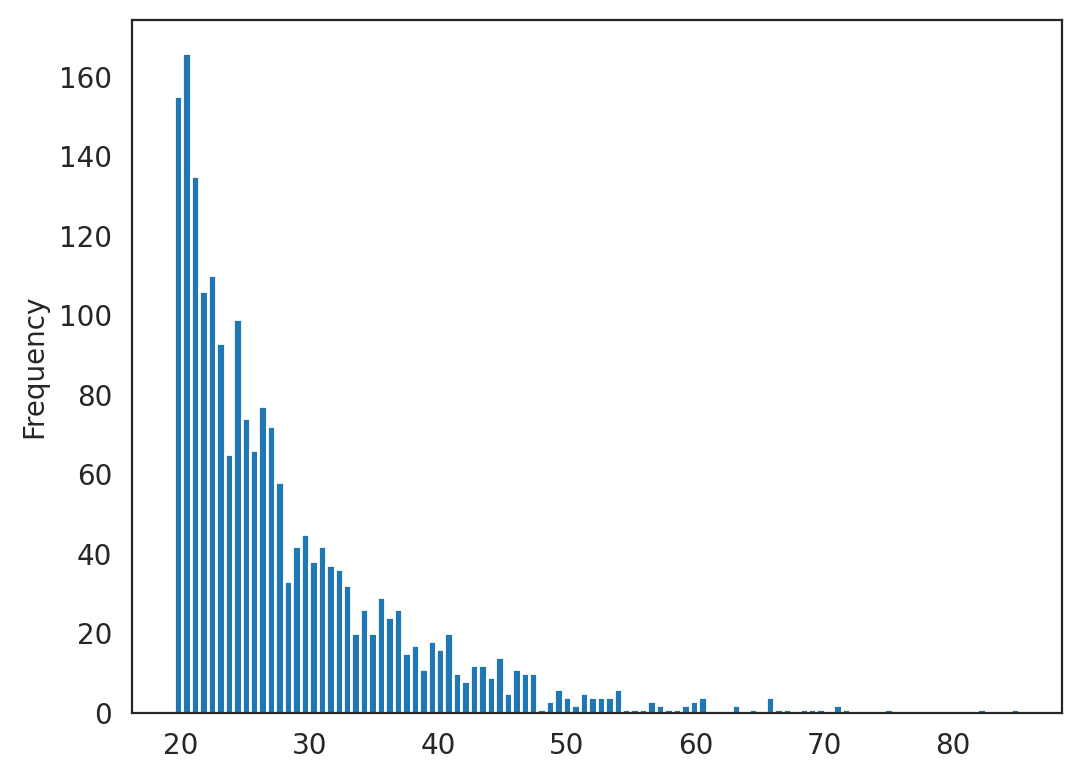

In [289]:
links.filtered_links["grnboost2_Microglia_B6J_adj"]["weight"].plot.hist(bins=100)

<AxesSubplot: ylabel='Frequency'>

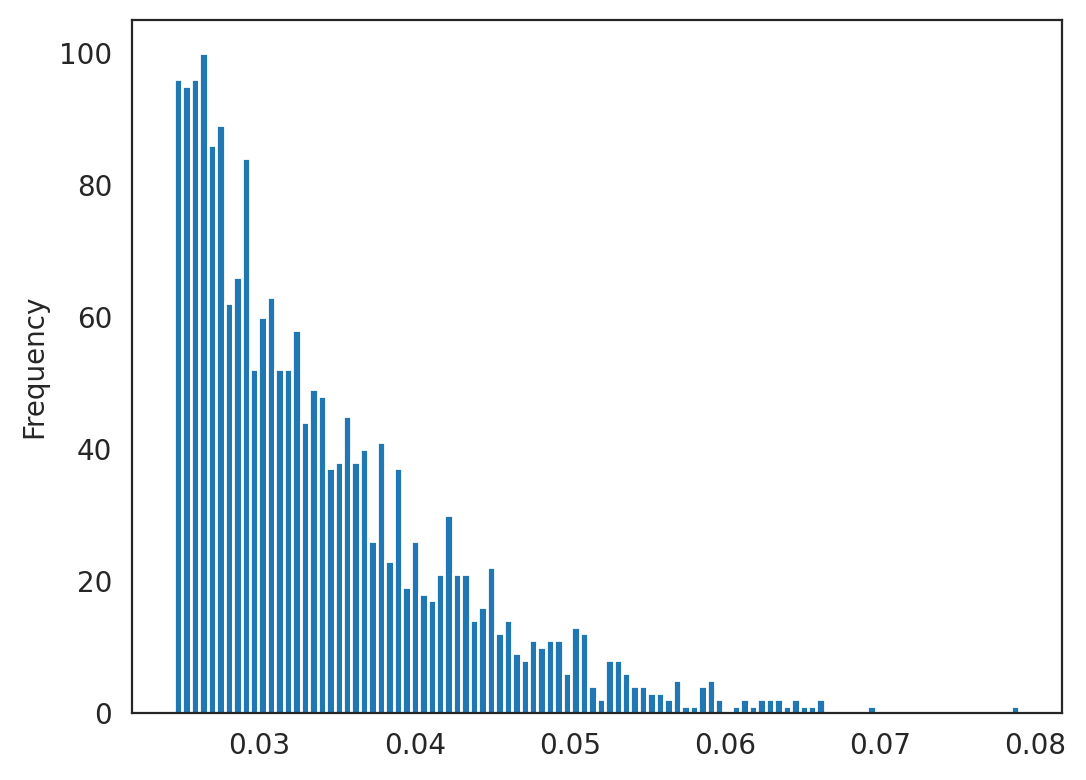

In [290]:
links.filtered_links["genie3_Microglia_B6J_adj"]["weight"].plot.hist(bins=100)

In [287]:
b6j_adj_list

,Pbx1,Srrm2,Zeb2,Celf2,Kmt2a,Cst3,Son,Mlxipl,Sfi1,Setbp1,...,Znrf1,Fxr1,Mgat5,Birc6,Dyrk1a,Trappc9,Kdm3a,Ccdc66,Cblb,Cdyl2
Pbx1,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Srrm2,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Zeb2,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Celf2,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Kmt2a,0.0,65.598416,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Trappc9,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Kdm3a,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Ccdc66,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
Cblb,0.0,0.000000,0,0.0,0,0,0.0,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [291]:
diff_adj = b6j_adj_list - castj_adj_list

In [292]:
def adj_mtx_to_list(adj_mtx):
    """Converts adjacency matrix to list of edges.

    Parameters
    ----------
    adj_mtx : pd.DataFrame
        Adjacency matrix of the graph. Index and columns are the nodes.
    
    Returns
    -------
    pd.DataFrame
        List of edges with columns 'source', 'target', and 'weight'.
    """
    adj_mtx = adj_mtx.copy()
    adj_mtx = adj_mtx.stack().reset_index()
    adj_mtx.columns = ['source', 'target', 'weight']
    adj_mtx = adj_mtx[adj_mtx['weight'] != 0]
    return adj_mtx

In [296]:
diff_list = adj_mtx_to_list(diff_adj)

In [302]:
diff_list["coef_abs"] = diff_list["weight"].abs()

In [303]:
diff_links = co.Links(name="test_diff", links_dict={"genotype_diff": diff_list})

In [304]:
diff_links.filter_links(p=None, threshold_number=10000)

In [305]:
diff_links.get_network_score()

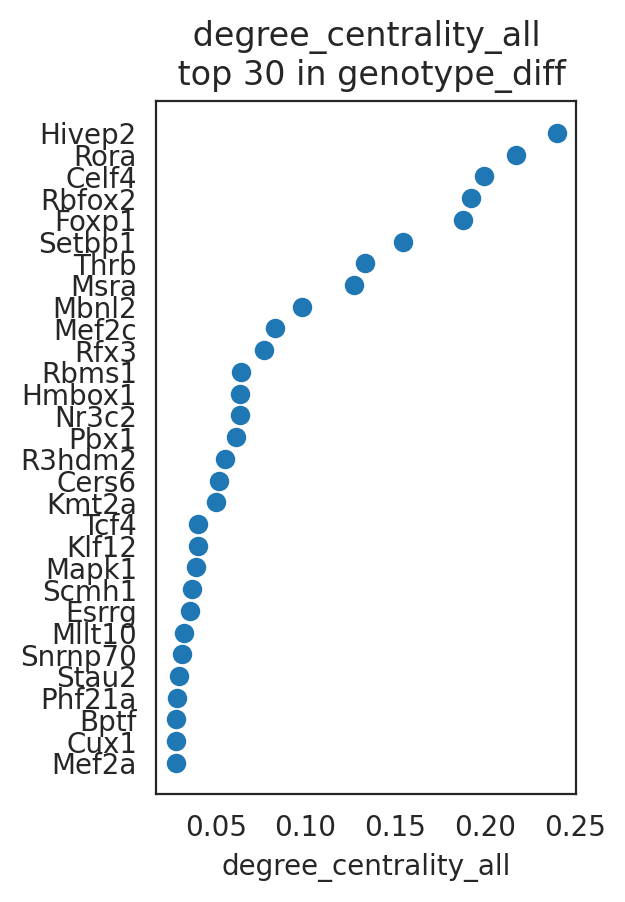

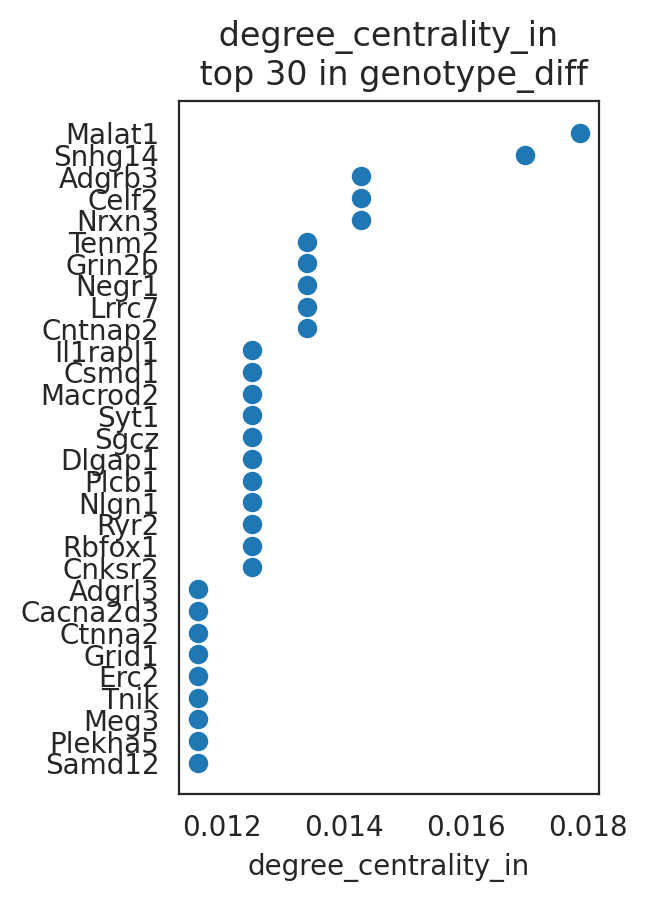

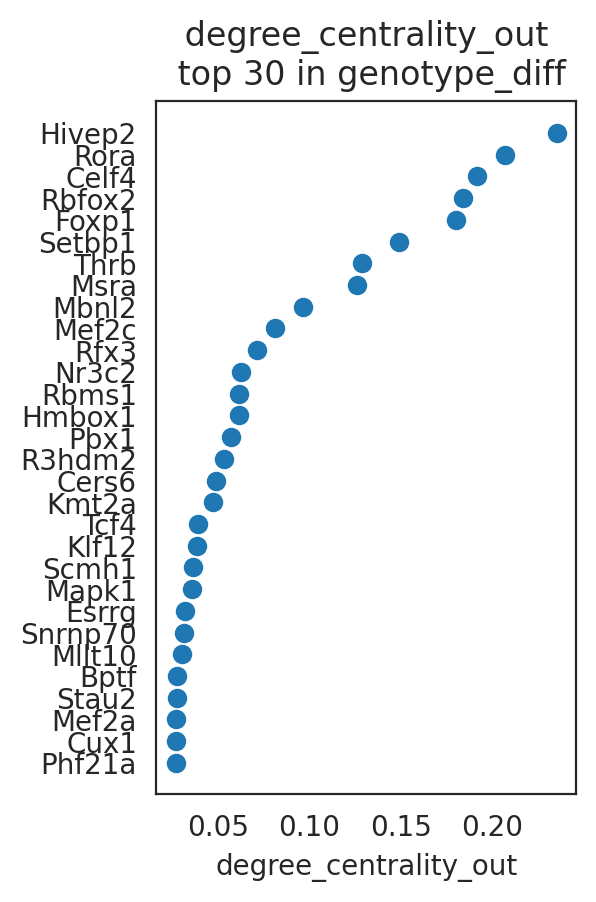

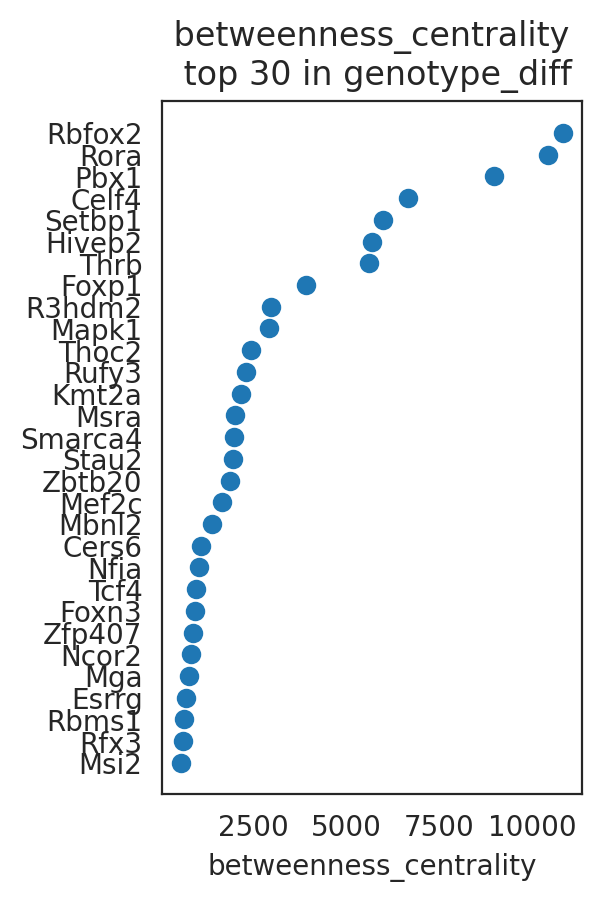

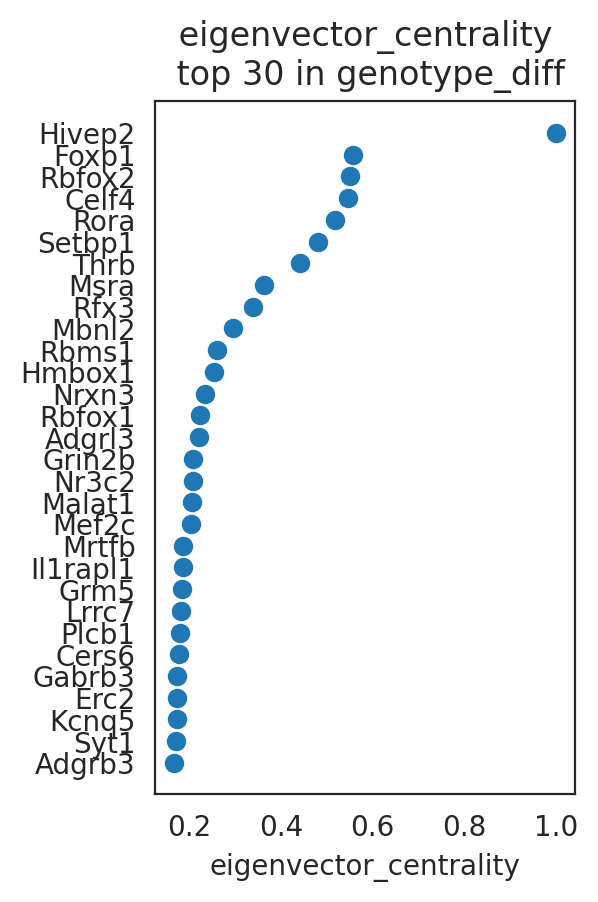

In [307]:
diff_links.plot_scores_as_rank(cluster="genotype_diff", n_gene=30)

In [76]:
b6_adj_list = links_to_adj(links.filtered_links["B6J"])

In [78]:
b6_adj_list.sum(axis=1).sort_values(ascending=False).head(10)

source
Hivep2    300
Celf4     200
Rbfox2    196
Setbp1    180
Thrb      176
Rora      158
Msra      114
Foxp1     102
Pbx1       58
Cers6      51
dtype: int64

In [80]:
b6_adj_list.sum(axis=0).sort_values(ascending=False).head(10)

target
Ptprn2                   11
Map2                     10
Gabrb3                   10
Macrod2                  10
ENSMUSG00000062991.10    10
Mdga2                     9
Grm7                      9
Gria2                     9
Anks1b                    9
Cntnap2                   9
dtype: int64

In [84]:
links.merged_score

,degree_all,degree_centrality_all,degree_in,degree_centrality_in,degree_out,degree_centrality_out,betweenness_centrality,eigenvector_centrality,cluster
Rora,165,0.303867,7,0.012891,158,0.290976,1552.0,0.557437,B6J
Tnik,8,0.014733,8,0.014733,0,0.000000,0.0,0.147032,B6J
ENSMUSG00000062991.10,10,0.018416,10,0.018416,0,0.000000,0.0,0.154670,B6J
Lrrc4c,8,0.014733,8,0.014733,0,0.000000,0.0,0.144982,B6J
Msi2,34,0.062615,7,0.012891,27,0.049724,293.0,0.052578,B6J
...,...,...,...,...,...,...,...,...,...
Papola,1,0.001597,1,0.001597,0,0.000000,0.0,0.000019,CASTJ
Tmcc3,1,0.001597,1,0.001597,0,0.000000,0.0,0.000008,CASTJ
Rsf1,1,0.001597,1,0.001597,0,0.000000,0.0,0.002910,CASTJ
Klhdc10,1,0.001597,1,0.001597,0,0.000000,0.0,0.003818,CASTJ
